In [26]:
import pandas as pd

df= pd.read_csv("ai_student_impact_dataset.csv")

info=df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

ossevare corr votazione, incremento, skill retention e burnout
Major_Category -> più colonne?
Year_of_Study -> diventa int 
Primary_Use_Case -> più colonne?
Prompt_Engineering_Skill -> int
Institutional_Policy -> int


In [27]:
df["GPA_increment"] = df["Post_Semester_GPA"]- df["Pre_Semester_GPA"]

In [28]:
df.value_counts(df["Burnout_Risk_Level"])
trad={"Low":1,"Medium":2,"High":3}
df["Burnout_Risk_Level"]=df["Burnout_Risk_Level"].map(trad)

In [29]:
df[["Burnout_Risk_Level","GPA_increment","Post_Semester_GPA","Skill_Retention_Score"]].corr()

,Burnout_Risk_Level,GPA_increment,Post_Semester_GPA,Skill_Retention_Score
Burnout_Risk_Level,1.000000,-0.006818,-0.095543,-0.058140
GPA_increment,-0.006818,1.000000,0.277146,0.195833
Post_Semester_GPA,-0.095543,0.277146,1.000000,0.169616
Skill_Retention_Score,-0.058140,0.195833,0.169616,1.000000


togliamo ora il target e info su Burnout e Skill Retention

In [30]:
y= df["GPA_increment"].copy()
df.drop(columns=["Burnout_Risk_Level","Skill_Retention_Score"], inplace=True)

In [31]:
df.drop(columns="Student_ID",inplace=True)

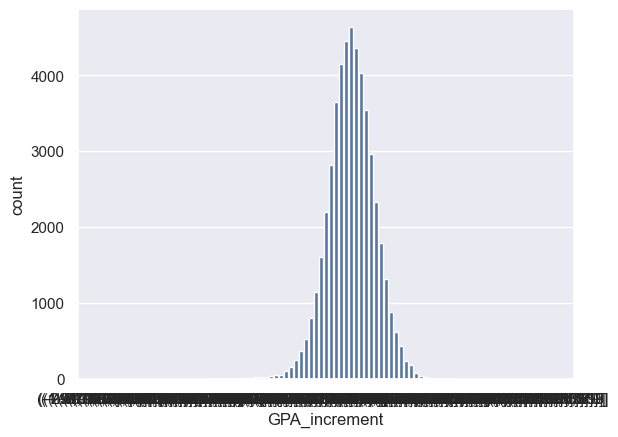

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

gruppi = pd.cut(y, np.linspace(-2,2,100))

sns.countplot(x=gruppi)
plt.show()


In [33]:
df.value_counts(df["Major_Category"])

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

fare modelli diversi per percorsi diversi?

In [34]:
trad={
"Junior": 3 ,
"Freshman" : 1,
"Senior"  : 4, 
"Sophomore"  : 2,
"Graduate" : 5,
}

df["Year_of_Study"]=df["Year_of_Study"].map(trad)

print(df["Year_of_Study"].unique())

[4 3 1 2 5]


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  str    
 1   Year_of_Study               50000 non-null  int64  
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  str    
 5   Prompt_Engineering_Skill    50000 non-null  str    
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  str    
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  GPA_increment               50000 non-null

In [36]:
for corso in df["Primary_Use_Case"].unique():
    df["is_"+corso]= df["Primary_Use_Case"]==corso

df.drop(columns="Primary_Use_Case",inplace=True)

In [37]:
df.value_counts(df["Prompt_Engineering_Skill"])

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [38]:
trad={
"Beginner": 1 ,
"Intermediate" : 2,
"Advanced"  : 3, 
}

df["Prompt_Engineering_Skill"]=df["Prompt_Engineering_Skill"].map(trad)

print(df["Prompt_Engineering_Skill"].unique())

[1 3 2]


In [39]:

df.value_counts(df["Institutional_Policy"])

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [40]:
for corso in df["Institutional_Policy"].unique():
    df["is_"+corso]= df["Institutional_Policy"]==corso

df.drop(columns="Institutional_Policy",inplace=True)

primo approccio mantenere categorie tutte assieme nello stesso dataset ma in colonne diverse e vediamo (poi dopo proviamo a dividere dataset per fare 5 modelli diversi)

In [41]:
df_by_category = df.copy() #salvo una copia del dataset per poi usarlo dopo per creare modelli separati

In [42]:
for corso in df["Major_Category"].unique():
    df["major_is_"+corso]= df["Major_Category"]==corso

df.drop(columns="Major_Category",inplace=True)

In [43]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
df.drop(columns="GPA_increment",inplace=True,errors=True)
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

modello baseline

In [44]:
from xgboost import XGBRegressor

rf_model = XGBRegressor(
    n_estimators=100,
    random_state=42
)


rf_model.fit(X_train, y_train) 

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [45]:
predictions = rf_model.predict(X_test)

print(mean_absolute_error(y_test, predictions))

print(r2_score(y_test, predictions))

0.013894464762454643
0.988228633127005


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 50000 non-null  int64  
 1   Pre_Semester_GPA              50000 non-null  float64
 2   Weekly_GenAI_Hours            50000 non-null  float64
 3   Prompt_Engineering_Skill      50000 non-null  int64  
 4   Tool_Diversity                50000 non-null  int64  
 5   Paid_Subscription             50000 non-null  bool   
 6   Traditional_Study_Hours       50000 non-null  float64
 7   Perceived_AI_Dependency       50000 non-null  int64  
 8   Anxiety_Level_During_Exams    50000 non-null  int64  
 9   Post_Semester_GPA             50000 non-null  float64
 10  is_Copywriting/Drafting       50000 non-null  bool   
 11  is_Ideation                   50000 non-null  bool   
 12  is_Summarizing_Reading        50000 non-null  bool   
 13  is_Debugging

In [46]:
# un dataframe per ogni categoria
df_dict={
    k:df_by_category[df_by_category["Major_Category"] == k]  for k in df_by_category["Major_Category"].unique()
}


In [ ]:
for d in df_dict.values():
    d.drop(columns=["Major_Category"], inplace=True)
    d.drop(columns=["GPA_increment"], inplace=True)
d.info()

df_dict["Tutti i major"]=df


In [55]:
model_params_major_dict={}

import optuna

def objective(trial):

    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'enable_categorical':True,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'bootstrap_type': "Bayesian",
        
       
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3,18),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True)
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif params["bootstrap_type"] == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    model = XGBRegressor(**params)

    model.fit(X_train, y_train,verbose=1)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae


In [56]:
best_model_major_dict={}
import seaborn as sns
for corso in df_dict.keys():
    
    print(f"major {corso}")
    c=corso

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    
    optimal_params = study.best_trial.params
    model_params_major_dict[corso]=optimal_params
    model=XGBRegressor(**optimal_params)
    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train,y_train)
    preds = model.predict(X_test)

    print("business mae:", mean_absolute_error(y_test, preds))
    print("business r2:", r2_score(y_test, preds))
    best_model_major_dict[corso]=model







    


[I 2026-06-05 09:36:28,991] A new study created in memory with name: no-name-6d84778b-1a5d-4c00-8ba6-836c5b7b9062


major Humanities


[I 2026-06-05 09:36:29,568] Trial 0 finished with value: 0.12357408259068803 and parameters: {'n_estimators': 245, 'learning_rate': 0.048053034887953865, 'max_depth': 12, 'subsample': 0.615626160529694, 'colsample_bytree': 0.9324604868595906, 'reg_alpha': 0.189156304007808, 'bagging_temperature': 1.8769166765347334}. Best is trial 0 with value: 0.12357408259068803.
[I 2026-06-05 09:36:30,229] Trial 1 finished with value: 0.1634046532495908 and parameters: {'n_estimators': 230, 'learning_rate': 0.012107657105957077, 'max_depth': 14, 'subsample': 0.9935659069802243, 'colsample_bytree': 0.6086022640960745, 'reg_alpha': 0.32152918069967773, 'bagging_temperature': 9.220207122897312}. Best is trial 0 with value: 0.12357408259068803.
[I 2026-06-05 09:36:31,892] Trial 2 finished with value: 0.14113041778133179 and parameters: {'n_estimators': 157, 'learning_rate': 0.025985513695430142, 'max_depth': 18, 'subsample': 0.9140431581879407, 'colsample_bytree': 0.8379201685944426, 'reg_alpha': 0.0011

Number of finished trials: 100
Best trial:
  Value: 0.11515546187572089
  Params: 
    n_estimators: 231
    learning_rate: 0.08485501424093733
    max_depth: 3
    subsample: 0.7803170482167702
    colsample_bytree: 0.6990953180666453
    reg_alpha: 0.8720200457897309
    bagging_temperature: 6.2084371534019605
business mae: 0.11557515471383535
business r2: 0.9152643370166452
major Medical


[I 2026-06-05 09:36:44,151] Trial 1 finished with value: 0.11913938724111629 and parameters: {'n_estimators': 185, 'learning_rate': 0.04155577121606063, 'max_depth': 6, 'subsample': 0.8758379473958597, 'colsample_bytree': 0.7289752645061396, 'reg_alpha': 0.0010313885025815181, 'bagging_temperature': 7.339763480885582}. Best is trial 1 with value: 0.11913938724111629.
[I 2026-06-05 09:36:44,205] Trial 2 finished with value: 0.12235643146656179 and parameters: {'n_estimators': 189, 'learning_rate': 0.050531624414440486, 'max_depth': 3, 'subsample': 0.6504585621687689, 'colsample_bytree': 0.7773089072149769, 'reg_alpha': 9.191042207953831, 'bagging_temperature': 9.50305499048283}. Best is trial 1 with value: 0.11913938724111629.
[I 2026-06-05 09:36:44,253] Trial 3 finished with value: 0.31403288662139284 and parameters: {'n_estimators': 165, 'learning_rate': 0.002670602357452245, 'max_depth': 3, 'subsample': 0.8274647323457467, 'colsample_bytree': 0.8054647405316018, 'reg_alpha': 6.283360

Number of finished trials: 100
Best trial:
  Value: 0.11535172346491873
  Params: 
    n_estimators: 232
    learning_rate: 0.08846792367727571
    max_depth: 3
    subsample: 0.7253296177586592
    colsample_bytree: 0.8306829704808444
    reg_alpha: 0.4697004877125168
    bagging_temperature: 2.9276743093092783
business mae: 0.11646155041897739
business r2: 0.9140818690607047
major Business


[I 2026-06-05 09:36:55,651] Trial 0 finished with value: 0.12229019514605569 and parameters: {'n_estimators': 220, 'learning_rate': 0.06870926072399548, 'max_depth': 8, 'subsample': 0.894154371271083, 'colsample_bytree': 0.6771951617768298, 'reg_alpha': 0.04937744104844731, 'bagging_temperature': 1.6975771032439424}. Best is trial 0 with value: 0.12229019514605569.
[I 2026-06-05 09:36:56,071] Trial 1 finished with value: 0.28208431077041507 and parameters: {'n_estimators': 250, 'learning_rate': 0.002566827116941871, 'max_depth': 10, 'subsample': 0.6988940672172885, 'colsample_bytree': 0.6546126225510016, 'reg_alpha': 0.029732822899583136, 'bagging_temperature': 4.532869971330448}. Best is trial 0 with value: 0.12229019514605569.
[I 2026-06-05 09:36:56,762] Trial 2 finished with value: 0.1280209768780491 and parameters: {'n_estimators': 236, 'learning_rate': 0.11946335489100426, 'max_depth': 13, 'subsample': 0.8001331585291651, 'colsample_bytree': 0.846955991924563, 'reg_alpha': 0.08702

Number of finished trials: 100
Best trial:
  Value: 0.11514978908351733
  Params: 
    n_estimators: 235
    learning_rate: 0.04150600061354056
    max_depth: 4
    subsample: 0.6165346344793333
    colsample_bytree: 0.9098407322968906
    reg_alpha: 0.0015222424607940046
    bagging_temperature: 7.2993848638132155
business mae: 0.11522258665497032
business r2: 0.9077600324117752
major STEM


[I 2026-06-05 09:37:11,530] Trial 0 finished with value: 0.2082119432299894 and parameters: {'n_estimators': 118, 'learning_rate': 0.009432782071592951, 'max_depth': 9, 'subsample': 0.7447754062557761, 'colsample_bytree': 0.7724985353178511, 'reg_alpha': 0.0018569055521637685, 'bagging_temperature': 4.1369245489513276}. Best is trial 0 with value: 0.2082119432299894.
[I 2026-06-05 09:37:11,760] Trial 1 finished with value: 0.2483109707623364 and parameters: {'n_estimators': 93, 'learning_rate': 0.007183640228121632, 'max_depth': 11, 'subsample': 0.8322136627718251, 'colsample_bytree': 0.9165920565520462, 'reg_alpha': 0.2472524307059683, 'bagging_temperature': 5.721497519783969}. Best is trial 0 with value: 0.2082119432299894.
[I 2026-06-05 09:37:12,272] Trial 2 finished with value: 0.33968895104586844 and parameters: {'n_estimators': 109, 'learning_rate': 0.002734661862944048, 'max_depth': 14, 'subsample': 0.6174266403524687, 'colsample_bytree': 0.6821655434150427, 'reg_alpha': 0.02620

Number of finished trials: 100
Best trial:
  Value: 0.11673074624357944
  Params: 
    n_estimators: 174
    learning_rate: 0.09848263277675925
    max_depth: 4
    subsample: 0.8907834005098374
    colsample_bytree: 0.783061474988478
    reg_alpha: 0.09875277472249397
    bagging_temperature: 3.8526292613339814
business mae: 0.11764992273787896
business r2: 0.9057552655604745
major Arts


[I 2026-06-05 09:37:27,345] Trial 0 finished with value: 0.150419932264185 and parameters: {'n_estimators': 192, 'learning_rate': 0.026266583224057564, 'max_depth': 15, 'subsample': 0.7222088942911762, 'colsample_bytree': 0.7236882003809232, 'reg_alpha': 0.009029143916999572, 'bagging_temperature': 2.4022317186092215}. Best is trial 0 with value: 0.150419932264185.
[I 2026-06-05 09:37:27,482] Trial 1 finished with value: 0.12614362116109049 and parameters: {'n_estimators': 56, 'learning_rate': 0.0819877518076645, 'max_depth': 17, 'subsample': 0.7074838414650576, 'colsample_bytree': 0.9160436140156609, 'reg_alpha': 0.6262973331568837, 'bagging_temperature': 3.880578296398695}. Best is trial 1 with value: 0.12614362116109049.
[I 2026-06-05 09:37:27,832] Trial 2 finished with value: 0.13614277677929693 and parameters: {'n_estimators': 171, 'learning_rate': 0.03874436490347586, 'max_depth': 11, 'subsample': 0.8452997199812545, 'colsample_bytree': 0.823164718415279, 'reg_alpha': 0.016103667

Number of finished trials: 100
Best trial:
  Value: 0.11863347626375166
  Params: 
    n_estimators: 208
    learning_rate: 0.0875743518781471
    max_depth: 3
    subsample: 0.670146601221331
    colsample_bytree: 0.8343427483447047
    reg_alpha: 1.0571096090659966
    bagging_temperature: 5.051776805286256
business mae: 0.1191375034182837
business r2: 0.9126982785106569
major Tutti i major


[I 2026-06-05 09:37:37,702] Trial 1 finished with value: 0.11264483103752136 and parameters: {'n_estimators': 208, 'learning_rate': 0.10887010945771328, 'max_depth': 6, 'subsample': 0.8593347455986526, 'colsample_bytree': 0.8951391305388938, 'reg_alpha': 7.427898962613941, 'bagging_temperature': 8.285873372578141}. Best is trial 1 with value: 0.11264483103752136.
[I 2026-06-05 09:37:37,942] Trial 2 finished with value: 0.11456168531284332 and parameters: {'n_estimators': 144, 'learning_rate': 0.1490290229078974, 'max_depth': 9, 'subsample': 0.8474923733287361, 'colsample_bytree': 0.8788544380679003, 'reg_alpha': 2.9497641920342965, 'bagging_temperature': 2.848612575874545}. Best is trial 1 with value: 0.11264483103752136.
[I 2026-06-05 09:37:38,186] Trial 3 finished with value: 0.33321111097831724 and parameters: {'n_estimators': 70, 'learning_rate': 0.0037088129998842207, 'max_depth': 12, 'subsample': 0.9507788288303067, 'colsample_bytree': 0.8097315011198589, 'reg_alpha': 1.531874086

Number of finished trials: 100
Best trial:
  Value: 0.111802573346138
  Params: 
    n_estimators: 239
    learning_rate: 0.09284019511027432
    max_depth: 4
    subsample: 0.903573293038154
    colsample_bytree: 0.9288795642073734
    reg_alpha: 0.8244124844377307
    bagging_temperature: 0.37584540903832786
business mae: 0.1119862578274727
business r2: 0.9161571662273411


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:38:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:38:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:38:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:38:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Humanities mae: 0.11557515471383535
Humanities r2: 0.9152643370166452
Medical mae: 0.11646155041897739
Medical r2: 0.9140818690607047
Business mae: 0.11522258665497032
Business r2: 0.9077600324117752


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:38:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:38:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:38:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


STEM mae: 0.11764992273787896
STEM r2: 0.9057552655604745
Arts mae: 0.1191375034182837
Arts r2: 0.9126982785106569
Tutti i major mae: 0.1119862578274727
Tutti i major r2: 0.9161571662273411


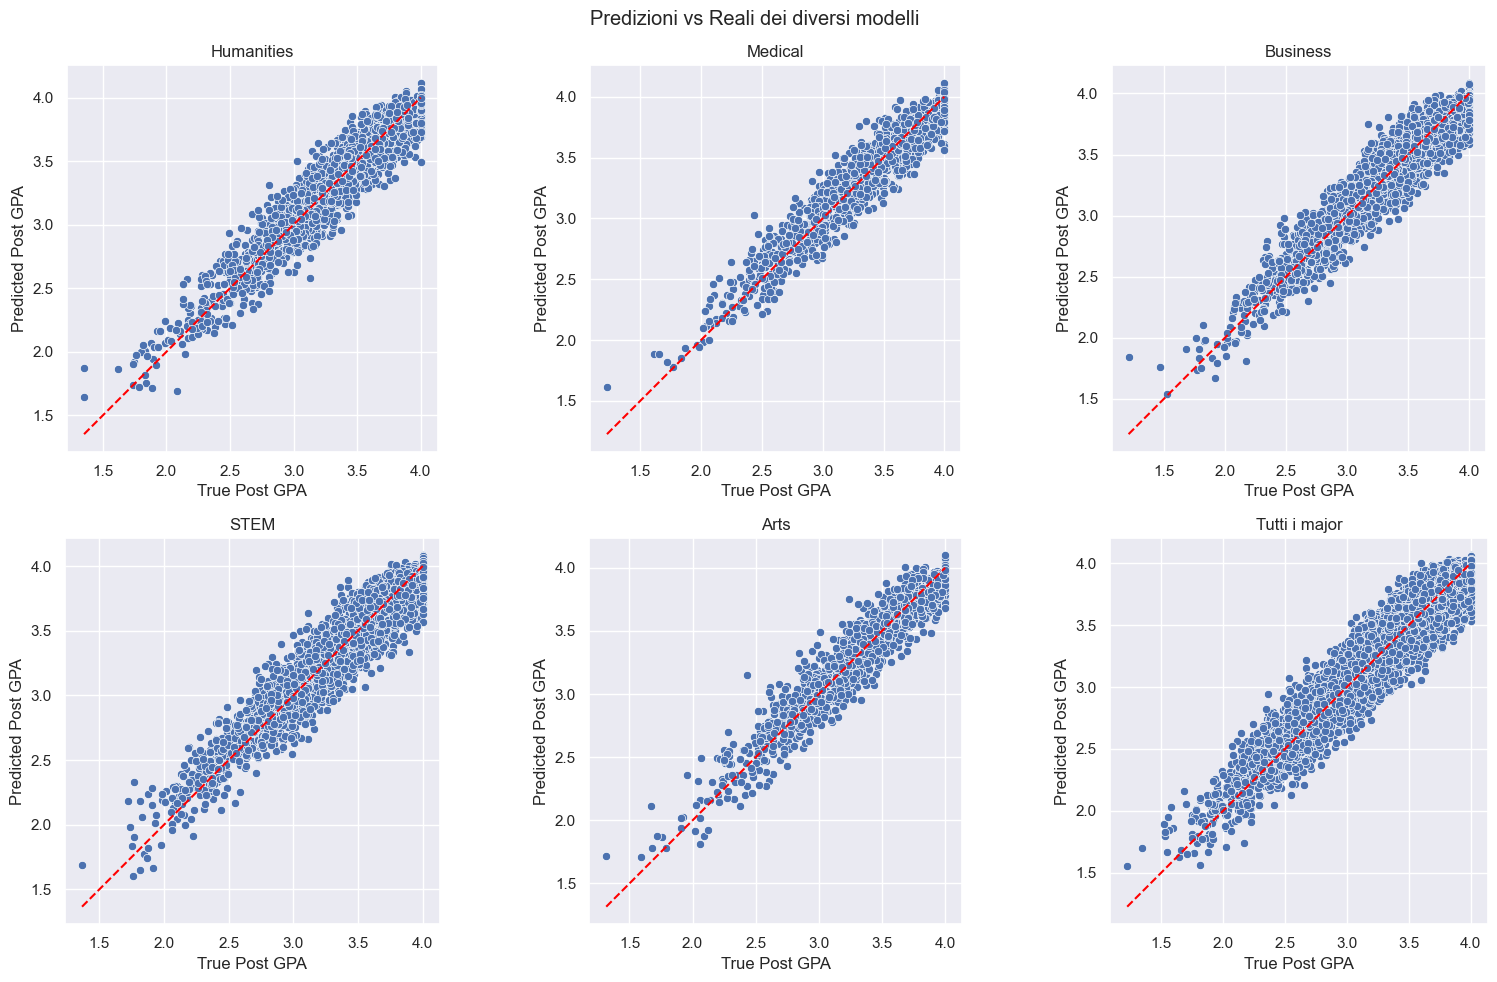

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
sns.set_theme(style='darkgrid')

for i, corso in enumerate(df_dict):
    optimal_params = model_params_major_dict[corso]

    model = XGBRegressor(**optimal_params)

    data = df_dict[corso]

    y = data["Post_Semester_GPA"]
    X = data.drop(columns="Post_Semester_GPA")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print(f"{corso} mae:", mean_absolute_error(y_test, preds))
    print(f"{corso} r2:", r2_score(y_test, preds))

    sns.scatterplot(
        x=y_test,
        y=preds,
        ax=axes[i]
    )

    axes[i].set_title(corso)
    axes[i].set_xlabel("True Post GPA")
    axes[i].set_ylabel("Predicted Post GPA")
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],c='red', linestyle='--',)

    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Predizioni vs Reali dei diversi modelli")
plt.tight_layout()
plt.show()